In [2]:
from google.colab import files
Uploaded=files.upload()

Saving healthcare_patient_analytics_seaborn.csv to healthcare_patient_analytics_seaborn.csv


In [6]:
import pandas as pd
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           5000 non-null   int64  
 1   visit_date           5000 non-null   object 
 2   age_group            5000 non-null   object 
 3   gender               5000 non-null   object 
 4   region               5000 non-null   object 
 5   department           5000 non-null   object 
 6   treatment_type       5000 non-null   object 
 7   visit_type           5000 non-null   object 
 8   length_of_stay_days  5000 non-null   float64
 9   treatment_cost       5000 non-null   float64
 10  recovery_score       5000 non-null   float64
 11  readmission_risk     5000 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 468.9+ KB


In [9]:
print(df.columns)

Index(['patient_id', 'visit_date', 'age_group', 'gender', 'region',
       'department', 'treatment_type', 'visit_type', 'length_of_stay_days',
       'treatment_cost', 'recovery_score', 'readmission_risk'],
      dtype='object')


In [10]:
df.columns = df.columns.str.strip()

In [11]:
df.isnull().sum()

,0
patient_id,0
visit_date,0
age_group,0
gender,0
region,0
department,0
treatment_type,0
visit_type,0
length_of_stay_days,0
treatment_cost,0


In [12]:
df["gender"].fillna(df["gender"].mode()[0], inplace=True)
df["region"].fillna(df["region"].mode()[0], inplace=True)

/tmp/ipykernel_1765/3279874587.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].fillna(df["gender"].mode()[0], inplace=True)
/tmp/ipykernel_1765/3279874587.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
len(df)

5000

In [17]:
print("GENDER COUNT")
print(df["gender"].value_counts())

print("\nDEPARTMENT COUNT")
print(df["department"].value_counts())

print("\nAVERAGE TREATMENT COST")
print(df["treatment_cost"].mean())

print("\nAVERAGE STAY DAYS")
print(df["length_of_stay_days"].mean())

print("\nREADMISSION RISK")
print(df["readmission_risk"].value_counts())

GENDER COUNT
gender
Male      2508
Female    2492
Name: count, dtype: int64

DEPARTMENT COUNT
department
Orthopedics         1058
Cardiology           995
General Medicine     991
Pediatrics           989
Neurology            967
Name: count, dtype: int64

AVERAGE TREATMENT COST
54915.4718

AVERAGE STAY DAYS
4.05966

READMISSION RISK
readmission_risk
0.15    142
0.19    140
0.20    133
0.23    129
0.18    124
       ... 
0.78      2
0.82      2
0.76      2
0.81      1
0.84      1
Name: count, Length: 83, dtype: int64


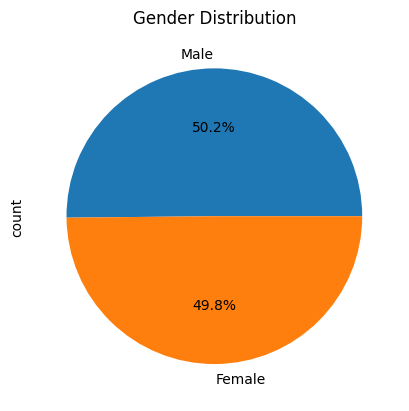

In [20]:
import matplotlib.pyplot as plt

df["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

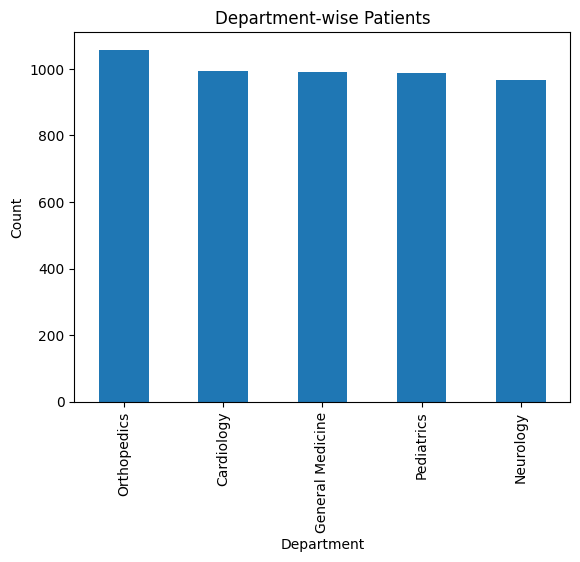

In [21]:
df["department"].value_counts().plot(kind="bar")
plt.title("Department-wise Patients")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

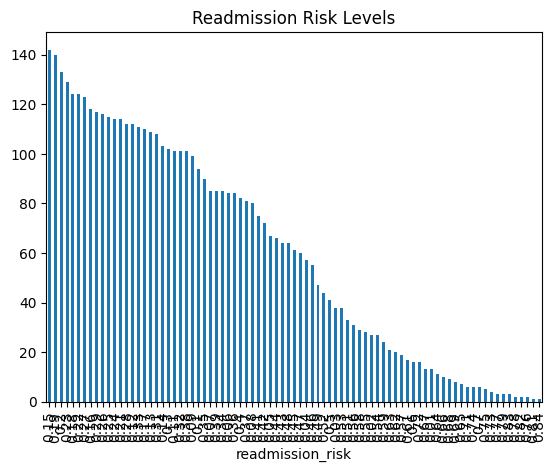

In [22]:
df["readmission_risk"].value_counts().plot(kind="bar")
plt.title("Readmission Risk Levels")
plt.show()

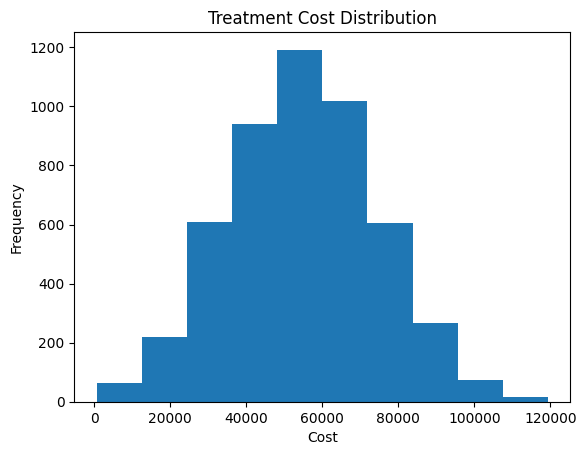

In [23]:
df["treatment_cost"].plot(kind="hist", bins=10)
plt.title("Treatment Cost Distribution")
plt.xlabel("Cost")
plt.show()

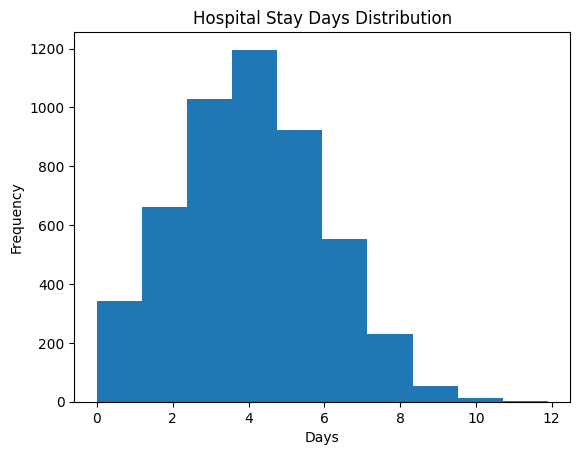

In [24]:
df["length_of_stay_days"].plot(kind="hist", bins=10)
plt.title("Hospital Stay Days Distribution")
plt.xlabel("Days")
plt.show()

In [25]:
print("INSIGHTS:")
print("1. Most patients belong to:", df["department"].value_counts().idxmax())
print("2. Most common gender:", df["gender"].mode()[0])
print("3. Average treatment cost:", df["treatment_cost"].mean())
print("4. Average hospital stay:", df["length_of_stay_days"].mean())
print("5. Most common risk level:", df["readmission_risk"].mode()[0])

INSIGHTS:
1. Most patients belong to: Orthopedics
2. Most common gender: Male
3. Average treatment cost: 54915.4718
4. Average hospital stay: 4.05966
5. Most common risk level: 0.15


In [26]:
df.to_csv("final_healthcare_cleaned.csv", index=False)